<a href="https://colab.research.google.com/github/Sharddha-Sharddha/CNN-MedMNIST/blob/main/MedMNIST_cnn_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🏥 MEDICAL IMAGE CLASSIFICATION WITH CNN**

*******************************************************

PROJECT TITLE: MedMNIST - Biomedical Image Classifier

OBJECTIVE:
Build an AI model that can automatically identify/classify medical images

**BloodMNIST Dataset Overview:**
- Total Images: ~17,092 blood cell microscope images
- Image Size: 28 x 28 pixels (colored RGB)
- Classes: Different types of blood cells
- Purpose: Detect abnormalities and cell types

In [1]:
!pip install -q tensorflow
!pip install -q keras_tuner

!pip install -q MedMNIST


In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from PIL import Image, ImageOps
import os

import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers, models, callbacks

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Enable Mixed Precision for faster training on modern GPUs (e.g., Tesla T4, V100)
# The policy 'mixed_float16' instructs Keras to use float16 for heavy computations
# while keeping variables in float32 for numeric stability.

from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

Compute dtype: float16
Variable dtype: float32


In [4]:
# data loader
from medmnist import BloodMNIST



In [5]:
train_data = BloodMNIST(split = 'train', download = True)
val_data = BloodMNIST(split = 'val', download = True)
test_data = BloodMNIST(split = 'test', download = True)
print("*********BloodMNIST dataset loaded successfully!************")

*********BloodMNIST dataset loaded successfully!************


In [6]:
train_data

Dataset BloodMNIST of size 28 (bloodmnist)
    Number of datapoints: 11959
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
    Number of samples: {'train': 11959, 'val': 1712, 'test': 3421}
    Description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
    License: CC B

In [7]:
print(f"\nTraining Images: {len(train_data)}")
print(f"Validation Images: {len(val_data)}")
print(f"Test Images: {len(test_data)}")

print(f"\nTotal Images: {len(train_data) + len(val_data) + len(test_data)}")



Training Images: 11959
Validation Images: 1712
Test Images: 3421

Total Images: 17092


In [8]:
train_images,train_labels = train_data.imgs, train_data.labels
test_images, test_labels = test_data.imgs, test_data.labels
val_images, val_labels = val_data.imgs, val_data.labels

In [9]:
print(f'training data shape - {train_images.shape}')  # total image 11959 ,pxl are 28*28 and 3 channel information
print(f'testing data shape - {test_images.shape}')
print(f'Validation data shape - {val_images.shape}')

training data shape - (11959, 28, 28, 3)
testing data shape - (3421, 28, 28, 3)
Validation data shape - (1712, 28, 28, 3)


In [10]:
train_images[47]

array([[[223, 183, 192],
        [207, 168, 173],
        [214, 176, 173],
        ...,
        [201, 159, 145],
        [212, 174, 155],
        [217, 179, 158]],

       [[238, 199, 202],
        [206, 168, 167],
        [204, 167, 159],
        ...,
        [224, 182, 168],
        [234, 196, 177],
        [239, 201, 180]],

       [[255, 223, 215],
        [243, 206, 197],
        [217, 181, 167],
        ...,
        [238, 196, 182],
        [246, 208, 189],
        [249, 211, 190]],

       ...,

       [[253, 230, 198],
        [249, 226, 195],
        [255, 229, 202],
        ...,
        [218, 180, 167],
        [222, 184, 173],
        [223, 183, 173]],

       [[252, 228, 202],
        [251, 225, 200],
        [254, 228, 205],
        ...,
        [219, 181, 170],
        [222, 184, 173],
        [223, 185, 174]],

       [[252, 225, 206],
        [251, 224, 205],
        [254, 225, 207],
        ...,
        [218, 182, 170],
        [220, 184, 172],
        [225, 187, 176]]], dtype=uint8)

In [11]:
test_labels[47]

array([1], dtype=uint8)

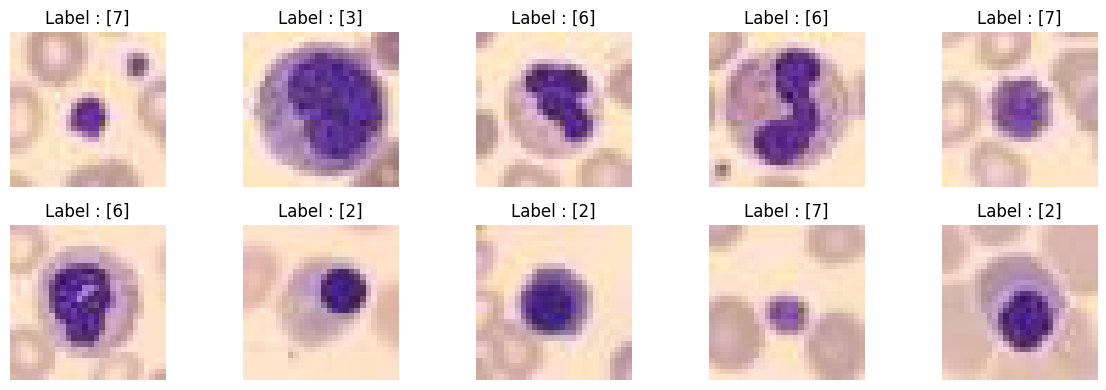

In [12]:
plt.figure(figsize = (12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  img = train_images[i]
  plt.imshow(img)
  plt.title(f'Label : {train_labels[i]}')
  plt.axis('off')
plt.tight_layout()

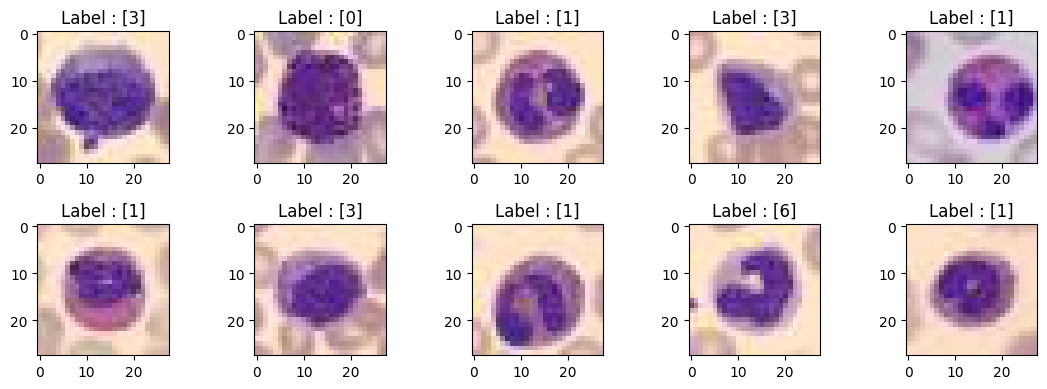

In [13]:
plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  tst_img = test_images[i]
  plt.imshow(tst_img)
  plt.title(f'Label : {test_labels[i]}')
  plt.tight_layout()

In [14]:
#normalisizing the data Pixel values in the RGB images range from [0, 255].
#Neural networks optimize significantly faster when values are scaled to the range [0.0, 1.0].

train_images = train_images.astype('float32')/255.0
test_images = test_images.astype('float32')/255.0
val_images = val_images.astype('float32')/255.0

train_images[1]

array([[[1.        , 0.9098039 , 0.8352941 ],
        [0.99607843, 0.8901961 , 0.80784315],
        [0.9843137 , 0.88235295, 0.78431374],
        ...,
        [0.6862745 , 0.5254902 , 0.5568628 ],
        [0.6313726 , 0.46666667, 0.5137255 ],
        [0.6117647 , 0.4509804 , 0.5137255 ]],

       [[0.99215686, 0.8901961 , 0.7921569 ],
        [1.        , 0.9019608 , 0.8039216 ],
        [1.        , 0.9098039 , 0.8039216 ],
        ...,
        [0.64705884, 0.4862745 , 0.5176471 ],
        [0.61960787, 0.45490196, 0.50980395],
        [0.61960787, 0.45882353, 0.52156866]],

       [[0.9764706 , 0.8784314 , 0.75686276],
        [1.        , 0.9098039 , 0.7882353 ],
        [1.        , 0.91764706, 0.79607844],
        ...,
        [0.6627451 , 0.49803922, 0.54509807],
        [0.654902  , 0.49411765, 0.5568628 ],
        [0.68235296, 0.52156866, 0.5921569 ]],

       ...,

       [[0.99607843, 0.9137255 , 0.7372549 ],
        [0.99607843, 0.9137255 , 0.74509805],
        [0.99607843, 0

In [15]:
train_images.shape

(11959, 28, 28, 3)

In [16]:
train_labels.shape

(11959, 1)

In [17]:
#.squeeze() flattens [[0], [3], [1], [5]] into [0, 3, 1, 5].
#The shape changes from (4, 1) to a simple (4,).
#It gets rid of that useless extra dimension of size 1.
train_labels = train_labels.squeeze()
test_labels = test_labels.squeeze()
val_labels = val_labels.squeeze()


train_labels.shape

(11959,)

In [18]:
# 4. Extract class metadata from train_data info
labels_dict = train_data.info['label']
n_classes = len(labels_dict)
class_names = [labels_dict[str(i)] for i in range(n_classes)]

print("Label shapes:", train_labels.shape, val_labels.shape, test_labels.shape)
print(f"Number of classes: {n_classes}")
class_names

Label shapes: (11959,) (1712,) (3421,)
Number of classes: 8


['basophil',
 'eosinophil',
 'erythroblast',
 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)',
 'lymphocyte',
 'monocyte',
 'neutrophil',
 'platelet']

In [32]:
# Data Augmentation (Creating Synthetic Variations)
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.40),
    layers.RandomFlip('Horizontal'),
    layers.RandomTranslation(0.1,0.1),
    layers.RandomZoom(0.30),
    layers.RandomContrast(0.1)
    ], name = 'data_augmentation')


# **# Constructing the CNN model architecture**

In [33]:
def create_model():

  model = models.Sequential([
    #first Convulation Block
    layers.Input(shape= (28,28,3)),
    data_augmentation,
    # Conv2D: Find patterns in images
    # 32 filters = detect 32 different patterns
    # (3,3) = look at 3x3 pixel windows
    # 'leaky_relu' = activation function (makes it non-linear)
    layers.Conv2D(32,(3,3), padding= 'same', activation= 'leaky_relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64,(3,3), padding= 'same', activation= 'leaky_relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.12),

    #second Convulation Block
    layers.Conv2D(64,(3,3), padding= 'same', activation= 'leaky_relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128,(3,3), padding= 'same', activation= 'leaky_relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    # flatten the layers
    layers.Flatten(),

    #ann Architecture
    layers.Dense(units = 256, activation= 'leaky_relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    layers.Dense(units = 128, activation= 'leaky_relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.60),

    layers.Dense(units = 8, activation='softmax')

  ], name = 'bloodMNIST')
  return model

In [34]:
model = create_model()

In [35]:
model.summary()

Model: "bloodMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857,160 (98.64 MB)

 Trainable params: 25,855,816 (98.63 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [36]:
# learning rate schedule - lr decay
# Gradually reduce the learning rate to fine-tune weights and avoid overshooting the minimum
lr_decy = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = 0.01,
    decay_steps = 1000,
    decay_rate = 0.90
)

In [37]:
optimizer= tf.keras.optimizers.Adam(learning_rate= lr_decy)

In [38]:
# Compiling the model
# Using sparse_categorical_crossentropy because labels are integers
model.compile(
    optimizer = optimizer,
    loss= 'sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

In [39]:
# callback mechanism
early_stoping = callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    mode = 'min'
)

checkpoint = callbacks.ModelCheckpoint(
    'best_blood_cell_model.keras',  # Save file name
    monitor = 'val_accuracy',
    mode = 'max',
    save_best_only = True,
    verbose = 1
)

callback = [early_stoping, checkpoint]

In [40]:
# model_training
history = model.fit(
    train_images,
    train_labels,
    batch_size = 128,
    epochs=30,
    validation_data = (val_images, val_labels),
    callbacks = callback
)

Epoch 1/30
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3686 - loss: 2.3005
Epoch 1: val_accuracy improved from None to 0.13727, saving model to best_blood_cell_model.keras

Epoch 1: finished saving model to best_blood_cell_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 169ms/step - accuracy: 0.5199 - loss: 1.5061 - val_accuracy: 0.1373 - val_loss: 13.9056
Epoch 2/30
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7055 - loss: 0.7798
Epoch 2: val_accuracy improved from 0.13727 to 0.13902, saving model to best_blood_cell_model.keras

Epoch 2: finished saving model to best_blood_cell_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.7308 - loss: 0.7312 - val_accuracy: 0.1390 - val_loss: 13.1338
Epoch 3/30
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7696 - loss: 0.6358
Epoch 3: val_accuracy improved from 0.13902 to 0.17231, saving model to best_blood_cell_model.keras

Epoch 3: finished saving model to best_blood_cell_model.keras
94/94 ━━━━━━━━━━━━━━━━━

In [31]:
# # Clear all cache
# !rm -rf ~/.keras
# !rm -rf ~/.cache
# !rm -rf /tmp/*

print("✅ Cache cleared!")

✅ Cache cleared!


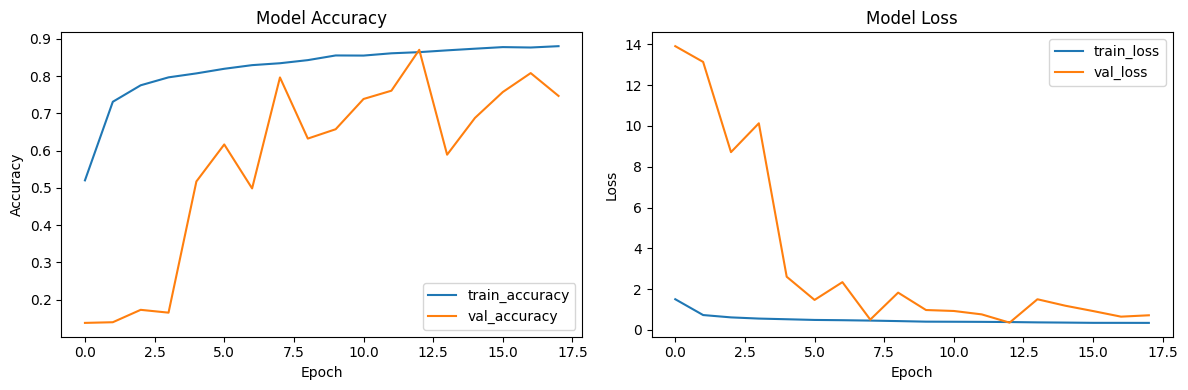

In [41]:
# Creating the figure and two subplots (axes)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='train_accuracy')
ax[0].plot(history.history['val_accuracy'], label='val_accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Plot Loss
ax[1].plot(history.history['loss'], label='train_loss')
ax[1].plot(history.history['val_loss'], label='val_loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()